In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df=pd.read_csv('COVIDItalyMATLAB_extended.csv',header=None)

In [5]:
df2=pd.read_csv('COVIDItalyMATLAB.csv',header=None)
df3 = pd.read_csv('COVIDItalyMATLAB.csv', header=None, usecols=lambda column: column not in [11, 12])

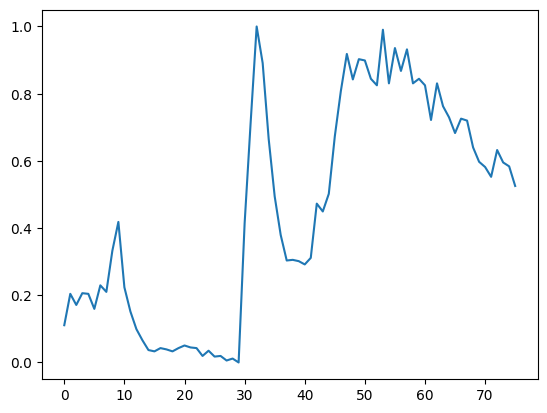

In [152]:
plt.plot(df_norm.iloc[:,10].to_numpy())
plt.show()

In [7]:
df3.iloc[0:11,:].T.describe()

,0,1,2,3,4,5,6,7,8,9,10
count,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000
mean,0.682379,0.273656,126333.750000,0.723684,0.407895,108.657895,325.763158,419.013158,12.947368,75.289474,261.710526
std,0.263668,0.382466,199868.691764,0.256836,0.415014,66.610020,194.966244,281.692527,3.136430,11.346442,168.781106
min,0.326193,0.000000,0.000000,0.000000,0.000000,44.000000,45.000000,17.000000,5.000000,47.000000,29.000000
25%,0.346916,0.000000,0.000000,0.500000,0.000000,54.000000,65.000000,41.750000,11.000000,68.750000,101.750000
50%,0.814644,0.000000,17178.000000,0.750000,0.250000,65.500000,430.000000,558.500000,13.000000,75.000000,266.000000
75%,0.896460,0.713432,169850.000000,1.000000,0.750000,180.500000,485.000000,647.000000,15.000000,85.000000,408.250000
max,0.997511,0.947777,721732.000000,1.000000,1.000000,250.000000,539.000000,739.000000,20.000000,94.000000,543.000000


In [8]:
df_norm = (df3.T-df3.T.min())/(df3.T.max()-df3.T.min())

In [15]:
min=df3.T.min()

In [16]:
max=df3.T.max()

In [14]:
df_norm.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12
count,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,7.600000e+01
mean,0.530577,0.288734,0.175042,0.723684,0.407895,0.313873,0.568346,0.556805,0.529825,0.601904,0.452744,0.192867,2.884897e-01
std,0.392762,0.403540,0.276929,0.256836,0.415014,0.323350,0.394669,0.390156,0.209095,0.241414,0.328368,0.305878,3.538602e-01
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,0.030869,0.000000,0.000000,0.500000,0.000000,0.048544,0.040486,0.034280,0.400000,0.462766,0.141537,0.000023,5.325680e-20
50%,0.727600,0.000000,0.023801,0.750000,0.250000,0.104369,0.779352,0.750000,0.533333,0.595745,0.461089,0.007605,6.433867e-02
75%,0.849474,0.752742,0.235337,1.000000,0.750000,0.662621,0.890688,0.872576,0.666667,0.808511,0.737840,0.279474,6.347764e-01
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00


In [10]:
#import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential(
    [
        layers.Dense(20, activation="tanh", input_shape=[11]),
        layers.Dense(20, activation="tanh"),
        layers.Dense(1),
    ]
)

model.compile(loss="mse", optimizer="adam")

#history = model.fit(df_norm.iloc[0:11,:].to_numpy().T, df_norm.iloc[12,:].to_numpy(), epochs=1000)
history = model.fit(df_norm.iloc[:,0:11].to_numpy(), df_norm.iloc[:,12].to_numpy(), epochs=1000)

print(history.history)


Epoch 1/1000
3/3 [==============================] - 1s 7ms/step - loss: 0.3238
Epoch 2/1000
3/3 [==============================] - 0s 5ms/step - loss: 0.1944
Epoch 3/1000
3/3 [==============================] - 0s 5ms/step - loss: 0.1154
Epoch 4/1000
3/3 [==============================] - 0s 5ms/step - loss: 0.0717
Epoch 5/1000
3/3 [==============================] - 0s 5ms/step - loss: 0.0589
Epoch 6/1000
3/3 [==============================] - 0s 6ms/step - loss: 0.0529
Epoch 7/1000
3/3 [==============================] - 0s 5ms/step - loss: 0.0460
Epoch 8/1000
3/3 [==============================] - 0s 5ms/step - loss: 0.0346
Epoch 9/1000
3/3 [==============================] - 0s 5ms/step - loss: 0.0234
Epoch 10/1000
3/3 [==============================] - 0s 5ms/step - loss: 0.0154
Epoch 11/1000
3/3 [==============================] - 0s 5ms/step - loss: 0.0117
Epoch 12/1000
3/3 [==============================] - 0s 6ms/step - loss: 0.0116
Epoch 13/1000
3/3 [==============================

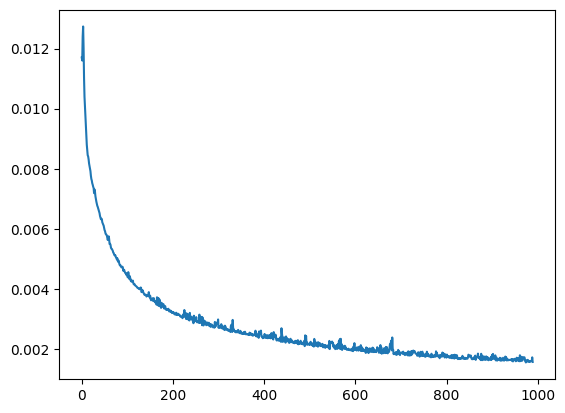

In [11]:
plt.plot(history.history['loss'][10:])
plt.show()

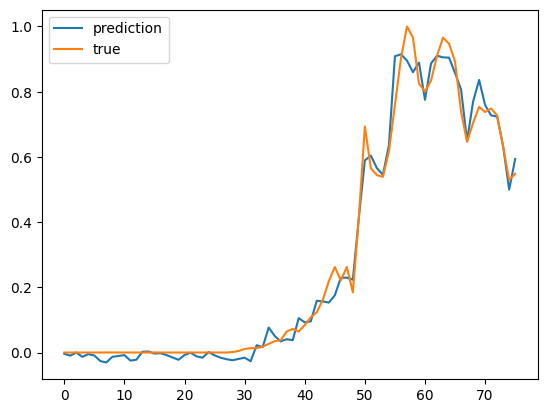

In [12]:
plt.plot(model(df_norm.iloc[:,0:11].to_numpy()))
plt.plot(df_norm.iloc[:,12].to_numpy())
plt.legend(['prediction','true'])
plt.show()

In [ ]:
true_values.shape

(76,)

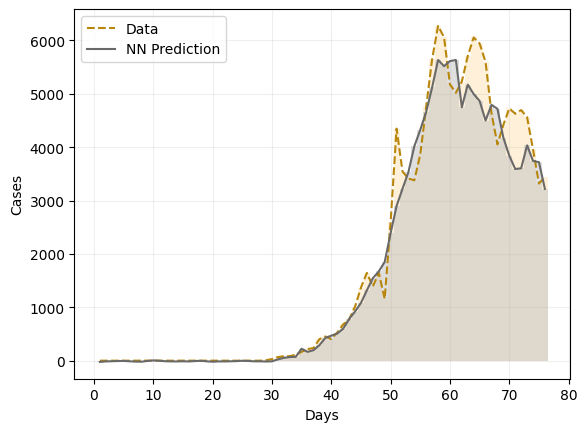

In [ ]:
plt.bar(np.linspace(1,76,76),df3.iloc[12,:].to_numpy(),color='moccasin', width=1.0, alpha=0.5)
plt.plot(np.linspace(1,76,76), df3.iloc[12,:].to_numpy(),'--',color='darkgoldenrod')
plt.bar(np.linspace(1,76,76), tf.squeeze(model(df3.iloc[0:11,:].to_numpy().T)),color='silver', width=1.0, alpha=0.5)
plt.plot(np.linspace(1,76,76), tf.squeeze(model(df3.iloc[0:11,:].to_numpy().T)),color='dimgrey')

plt.xlabel('Days')
plt.ylabel('Cases')
plt.legend(['Data', 'NN Prediction'])
plt.grid(True,alpha=0.2)
plt.savefig('Cov_pred.png', dpi=300)
plt.show()

In [ ]:
model.save('covid_model.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [17]:
import sys
if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/CBE60499/main/notebooks/helper.py"
    import helper
    helper.install_idaes()
    helper.install_ipopt()
    !pyomo build-extensions

from pyomo.environ import *
from pyomo.dae import *

--2024-05-20 20:03:10--  https://raw.githubusercontent.com/ndcbe/CBE60499/main/notebooks/helper.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7171 (7.0K) [text/plain]
Saving to: ‘helper.py’

helper.py           100%[===================>]   7.00K  --.-KB/s    in 0s      

2024-05-20 20:03:10 (79.7 MB/s) - ‘helper.py’ saved [7171/7171]

Installing idaes via pip...
idaes was successfully installed
Running idaes get-extensions to install Ipopt, k_aug, and more...
Ipopt 3.13.2 (x86_64-pc-linux-gnu), ASL(20190605)

[K_AUG] 0.1.0, Part of the IDAES PSE framework
Please visit https://idaes.org/ (x86_64-pc-linux-gnu), ASL(20190605)

Couenne 0.5.8 -- an Open-Source solver for Mixed Integer Nonlinear Optimization
Mailing list: couenne@list.coin-or.org
Instructions

In [18]:
import matplotlib.pyplot as plt
import os
import argparse
import time
import numpy as np
import IPython
import pandas as pd
from scipy.interpolate import BSpline
from pyomo.environ import *
from pyomo.dae import *

In [19]:
!pip install git+https://github.com/cog-imperial/OMLT.git

  Cloning https://github.com/cog-imperial/OMLT.git to /tmp/pip-req-build-hc48zw4h
  Running command git clone --filter=blob:none --quiet https://github.com/cog-imperial/OMLT.git /tmp/pip-req-build-hc48zw4h
  Resolved https://github.com/cog-imperial/OMLT.git to commit e60563859a66ac5dd3348bf1763de57eec95171e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 3.3 MB/s eta 0:00:00
  Created wheel for omlt: filename=omlt-1.1.post1.dev121+ge605638-py2.py3-none-any.whl size=54368 sha256=8e0e4a79b57863fb008c1ea13096b2dc865c554a148006601506052b19d8bd20
  Stored in directory: /tmp/pip-ephem-wheel-cache-v2lqcyre/wheels/53/93/d9/b409664fba5342c98ad450fa3d16c577f8a9996068e8c513d0
Successfully built omlt
  Attempting uninstall: pyomo
    Found existing installation: Pyomo 6.7.2
    Uninstalling Pyomo-6.7.2:
      Successfully uninstalled Pyomo-6.7.2
ERROR: p

In [33]:
from omlt import OmltBlock, OffsetScaling
from omlt.neuralnet import FullSpaceNNFormulation, NetworkDefinition,ReluBigMFormulation,ReluComplementarityFormulation,ReducedSpaceNNFormulation
from omlt.io import load_keras_sequential

In [101]:
m=ConcreteModel()
m.tf=Param(initialize=750)
m.t =ContinuousSet(bounds=(0,m.tf))

M=0.091
b=0.091*2
p=80*1e6+1000

m.S=Var(m.t,initialize=80e6,bounds=(0,80e6))
m.I=Var(m.t,initialize=1000,bounds=(0,80e6))
m.R=Var(m.t,initialize=0,bounds=(0,80e6))
m.Q=Var(m.t,initialize=0,bounds=(0,80e6))
#m.U=Var(m.t,initialize=0,bounds=(0,0))
#m.S=Var(m.t,initialize=80e6)
#m.I=Var(m.t,initialize=1000)
#m.R=Var(m.t,initialize=0)
#m.Q=Var(m.t,initialize=0)
m.U=Var(m.t,initialize=0,bounds=(0,0.091))


m.dSdt = DerivativeVar(m.S,wrt=m.t)
m.dIdt = DerivativeVar(m.I,wrt=m.t)
m.dRdt = DerivativeVar(m.R,wrt=m.t)
m.dQdt = DerivativeVar(m.Q,wrt=m.t)

def _intU(m,t):
   return m.U[t]
m.intU = Integral(m.t,wrt=m.t,rule=_intU)

m.obj = Objective(expr=0.5*m.R[m.tf]+0.5*m.Q[m.tf]+0.5*m.Q[m.tf]+500000*m.intU,sense=minimize)
#m.obj = Objective(expr=0.0,sense=maximize)


def _x1dot(m,t):
    #if t==0:
     #   return Constraint.Skip
    return m.dSdt[t] == -b/p*m.S[t]*m.I[t]
m.x1dot=Constraint(m.t, rule=_x1dot)

def _x2dot(m,t):
    #if t==0:
    #    return Constraint.Skip
    return m.dIdt[t] == b/p*m.S[t]*m.I[t] -(M+m.U[t])*m.I[t]
m.x2dot=Constraint(m.t, rule=_x2dot)
def _x3dot(m,t):
    #if t==0:
    #    return Constraint.Skip
    return m.dRdt[t] ==M*m.I[t]
m.x3dot=Constraint(m.t, rule=_x3dot)
def _x4dot(m,t):
    #if t==0:
    #    return Constraint.Skip
    return m.dQdt[t] == m.U[t]*m.I[t]
m.x4dot=Constraint(m.t, rule=_x4dot)


#def _con(m,t):
#  return m.I[t]<=40000
#m.con = Constraint(m.t,rule=_con)

def _init(m):
  yield m.S[0]==80*1e6
  yield m.I[0]==1000
  yield m.Q[0]==0
  yield m.R[0]==0
m.init_conditions=ConstraintList(rule=_init)

In [102]:
#for t in m.t:
#    # Fix the variable m.U[t]
#    m.U[t].fix(0)
u_profile = {0: 0.02, 120: 0.02}

#Declaring a Pyomo Suffix to pass the time-varying inputs to the Simulator
m.var_input = Suffix(direction=Suffix.LOCAL)
m.var_input[m.U] = u_profile

discretizer = TransformationFactory('dae.collocation')
discretizer.apply_to(m, nfe=100, ncp=1)


sim = Simulator(m, package='scipy')
tsim, profiles = sim.simulate(numpoints=100, integrator='vode',varying_inputs=m.var_input)



sim.initialize_model()

In [103]:
#discretizer = TransformationFactory('dae.collocation')
#discretizer.apply_to(m, nfe=100, ncp=3, scheme='LAGRANGE-RADAU')
#discretizer = TransformationFactory('dae.finite_difference')
#discretizer.apply_to(m, nfe=100, scheme='FORWARD')
#discretizer.apply_to(m)
#discretizer.reduce_collocation_points(m, var=m.u, ncp=1, contset=m.t)

#for t in m.t:
#  m.U[t].fix(0.02)

solver = SolverFactory('ipopt')

results = solver.solve(m, tee=True)

x1 = []
x2 = []
x3 = []
x4 = []
u = []
t = []

print(sorted(m.t))

for i in sorted(m.t):
    t.append(i)
    x1.append(value(m.S[i]))
    x2.append(value(m.I[i]))
    x3.append(value(m.R[i]))
    x4.append(value(m.Q[i]))
    u.append(value(m.U[i]))

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

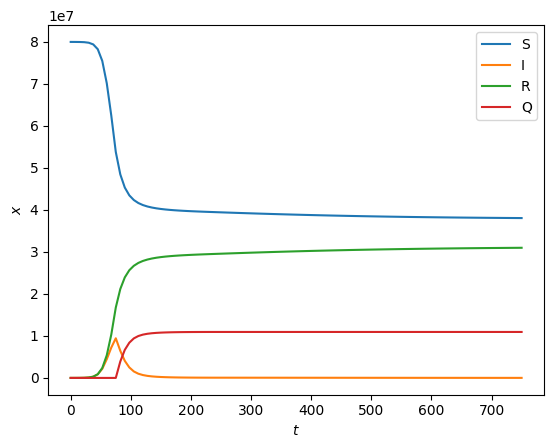

In [104]:
plt.plot(t, x1)
plt.plot(t, x2)
plt.plot(t, x3)
plt.plot(t, x4)
plt.xlabel('$t$')
plt.ylabel('$x$')
plt.legend(['S','I','R','Q'])
plt.show()


#plt.plot(t, u,'r--')
#plt.xlabel('$t$')
#plt.ylabel('$u$')
#plt.legend(['NODE','DAE'])

plt.show()

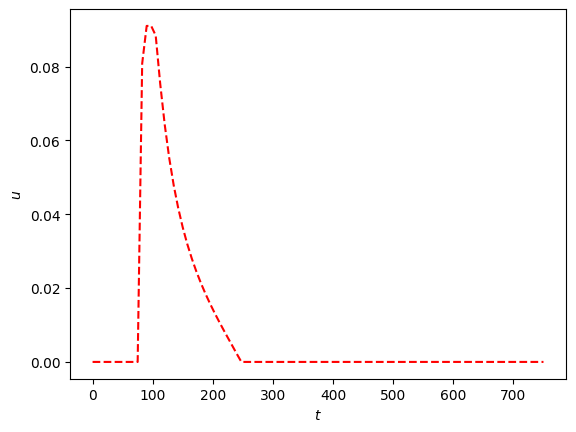

In [105]:
plt.plot(t, u,'r--')
plt.xlabel('$t$')
plt.ylabel('$u$')


plt.show()

In [26]:
from pyomo.core.base import Constraint, Param, value, Suffix, Block
from pyomo.dae import ContinuousSet, DerivativeVar
from pyomo.dae.diffvar import DAE_Error
import pyomo.core.expr as EXPR
from pyomo.core.expr.numvalue import native_numeric_types
from pyomo.core.expr.template_expr import IndexTemplate, _GetItemIndexer
from pyomo.common.dependencies import (
    numpy as np,
    numpy_available,
    scipy,
    scipy_available,
    attempt_import,
)

In [127]:
m=ConcreteModel()
m.tf=Param(initialize=750)
m.t =ContinuousSet(bounds=(0,m.tf))

M=0.091
b=0.091*2
p=80*1e6+1000

m.S=Var(m.t,initialize=80e6,bounds=(0,80e6))
m.I=Var(m.t,initialize=1000,bounds=(0,80e6))
m.R=Var(m.t,initialize=0,bounds=(0,80e6))
m.Q=Var(m.t,initialize=0,bounds=(0,80e6))
#m.U=Var(m.t,initialize=0,bounds=(0,0))
#m.S=Var(m.t,initialize=80e6)
#m.I=Var(m.t,initialize=1000)
#m.R=Var(m.t,initialize=0)
#m.Q=Var(m.t,initialize=0)
#m.U=Var(m.t,initialize=3364,bounds=(3000,3370))
m.U=Var(m.t,domain=NonNegativeReals)


m.dSdt = DerivativeVar(m.S,wrt=m.t)
m.dIdt = DerivativeVar(m.I,wrt=m.t)
m.dRdt = DerivativeVar(m.R,wrt=m.t)
m.dQdt = DerivativeVar(m.Q,wrt=m.t)

def _intU(m,t):
   return m.U[t]
m.intU = Integral(m.t,wrt=m.t,rule=_intU)

m.obj = Objective(expr=0.5*m.R[m.tf]+0.5*m.Q[m.tf]+0.5*m.Q[m.tf]+500000*m.intU,sense=minimize)
#m.obj = Objective(expr=0.0,sense=maximize)


def _x1dot(m,t):
    #if t==0:
     #   return Constraint.Skip
    return m.dSdt[t] == -b/p*m.S[t]*m.I[t]
m.x1dot=Constraint(m.t, rule=_x1dot)

def _x2dot(m,t):
    #if t==0:
    #    return Constraint.Skip
    return m.dIdt[t] == b/p*m.S[t]*m.I[t] -(M+m.U[t])*m.I[t]
m.x2dot=Constraint(m.t, rule=_x2dot)
def _x3dot(m,t):
    #if t==0:
    #    return Constraint.Skip
    return m.dRdt[t] ==M*m.I[t]
m.x3dot=Constraint(m.t, rule=_x3dot)
def _x4dot(m,t):
    #if t==0:
    #    return Constraint.Skip
    return m.dQdt[t] == m.U[t]*m.I[t]
m.x4dot=Constraint(m.t, rule=_x4dot)


#def _con(m,t):
#  return m.I[t]<=40000
#m.con = Constraint(m.t,rule=_con)

def _init(m):
  yield m.S[0]==80*1e6
  yield m.I[0]==1000
  yield m.Q[0]==0
  yield m.R[0]==0
m.init_conditions=ConstraintList(rule=_init)

discretizer = TransformationFactory('dae.collocation')
discretizer.apply_to(m, nfe=100, ncp=1, scheme='LAGRANGE-RADAU')

In [128]:
class Pyomo2Scipy_Visitor(EXPR.ExpressionReplacementVisitor):
    """
    Expression walker that replaces _GetItemExpression
    instances with mutable parameters.
    """

    def __init__(self, templatemap):
        # Note because we are creating a "nonPyomo" expression tree, we
        # want to remove all Expression nodes (as opposed to replacing
        # them in place)
        super().__init__(
            descend_into_named_expressions=True, remove_named_expressions=True
        )
        self.templatemap = templatemap

    def beforeChild(self, node, child, child_idx):
        if type(child) is IndexTemplate:
            return False, child

        if isinstance(child, EXPR.GetItemExpression):
            _id = _GetItemIndexer(child)
            if _id not in self.templatemap:
                self.templatemap[_id] = Param(mutable=True)
                self.templatemap[_id].construct()
                self.templatemap[_id]._name = "%s[%s]" % (
                    _id.base.name,
                    ','.join(str(x) for x in _id.args),
                )
            return False, self.templatemap[_id]

        return super().beforeChild(node, child, child_idx)

In [129]:
_intpackage='scipy'
def convert_pyomo2scipy(expr, templatemap):
    """Substitute _GetItem nodes in an expression tree.

    This substitution function is used to replace Pyomo _GetItem
    nodes with mutable Params.

    Args:
        templatemap: dictionary mapping _GetItemIndexer objects to
            mutable params

    Returns:
        a new expression tree with all substitutions done
    """
    if not scipy_available:
        raise DAE_Error(
            "SciPy is not installed. Cannot substitute SciPy intrinsic functions."
        )
    visitor = Pyomo2Scipy_Visitor(templatemap)
    return visitor.walk_expression(expr)
def _check_getitemexpression(expr, i):
    """
    Accepts an equality expression and an index value. Checks the
    GetItemExpression at expr.arg(i) to see if it is a
    :py:class:`DerivativeVar<pyomo.dae.DerivativeVar>`. If so, return the
    GetItemExpression for the :py:class:`DerivativeVar<DerivativeVar>` and
    the RHS. If not, return None.
    """
    if type(expr.arg(i).arg(0)) is DerivativeVar:
        return [expr.arg(i), expr.arg(1 - i)]
    else:
        return None

temp = m.component_map(ContinuousSet)
if len(temp) != 1:
    raise DAE_Error(
        "Currently the simulator may only be applied to "
        "Pyomo models with a single ContinuousSet"
    )

# Get the ContinuousSet in the model
contset = list(temp.values())[0]

# Create a index template for the continuous set
cstemplate = IndexTemplate(contset)

# Ensure that there is at least one derivative in the model
derivs = m.component_map(DerivativeVar)
derivs = list(derivs.keys())

if hasattr(m, '_pyomo_dae_reclassified_derivativevars'):
    for d in m._pyomo_dae_reclassified_derivativevars:
        derivs.append(d.name)
if len(derivs) == 0:
    raise DAE_Error("Cannot simulate a model with no derivatives")

templatemap = {}  # Map for template substituter
rhsdict = {}  # Map of derivative to its RHS templated expr
derivlist = []  # Ordered list of derivatives
alglist = []  # list of templated algebraic equations

# Loop over constraints to find differential equations with separable
# RHS. Must find a RHS for every derivative var otherwise ERROR. Build
# dictionary of DerivativeVar:RHS equation.
for con in m.component_objects(Constraint, active=True):
    # Skip the discretization equations if model is discretized
    if '_disc_eq' in con.name:
        continue

    # Check dimension of the Constraint. Check if the
    # Constraint is indexed by the continuous set and
    # determine its order in the indexing sets
    if con.dim() == 0:
        continue

    conindex = con.index_set()
    # if not hasattr(conindex, 'set_tuple'):
    #     # Check if the continuous set is the indexing set
    #     if conindex is not contset:
    #         continue
    #     else:
    #         csidx = 0
    #         noncsidx = (None,)
    # else:
    dimsum = 0
    csidx = -1
    noncsidx = None
    for s in conindex.subsets():
        if s is contset:
            if csidx != -1:
                raise DAE_Error(
                    "Cannot simulate the constraint %s because "
                    "it is indexed by duplicate ContinuousSets" % con.name
                )
            csidx = dimsum
        elif noncsidx is None:
            noncsidx = s
        else:
            noncsidx = noncsidx.cross(s)
        dimsum += s.dimen
    if csidx == -1:
        continue
    if noncsidx is None:
        noncsidx = (None,)

    # Get the rule used to construct the constraint
    conrule = con.rule

    for i in noncsidx:
        # Insert the index template and call the rule to
        # create a templated expression
        if i is None:
            tempexp = conrule(m, cstemplate)
        else:
            if not isinstance(i, tuple):
                i = (i,)
            tempidx = i[0:csidx] + (cstemplate,) + i[csidx:]
            tempexp = conrule(m, tempidx)

        # Check to make sure it's an EqualityExpression
        if not type(tempexp) is EXPR.EqualityExpression:
            continue

        # Check to make sure it's a differential equation with
        # separable RHS
        args = None
        # Case 1: m.dxdt[t] = RHS
        if isinstance(tempexp.arg(0), EXPR.GetItemExpression):
            args = _check_getitemexpression(tempexp, 0)

        # Case 2: RHS = m.dxdt[t]
        if args is None:
            if isinstance(tempexp.arg(1), EXPR.GetItemExpression):
                args = _check_getitemexpression(tempexp, 1)

        # Case 3: m.p*m.dxdt[t] = RHS
        if args is None:
            if (
                type(tempexp.arg(0)) is EXPR.ProductExpression
                or type(tempexp.arg(0)) is EXPR.DivisionExpression
            ):
                args = _check_productexpression(tempexp, 0)

        # Case 4: RHS =  m.p*m.dxdt[t]
        if args is None:
            if (
                type(tempexp.arg(1)) is EXPR.ProductExpression
                or type(tempexp.arg(1)) is EXPR.DivisionExpression
            ):
                args = _check_productexpression(tempexp, 1)

        # Case 5: m.dxdt[t] + sum(ELSE) = RHS
        # or CONSTANT + m.dxdt[t] = RHS
        if args is None:
            if type(tempexp.arg(0)) is EXPR.SumExpression:
                args = _check_viewsumexpression(tempexp, 0)

        # Case 6: RHS = m.dxdt[t] + sum(ELSE)
        if args is None:
            if type(tempexp.arg(1)) is EXPR.SumExpression:
                args = _check_viewsumexpression(tempexp, 1)

        # Case 7: RHS = m.p*m.dxdt[t] + CONSTANT
        # This case will be caught by Case 6 if p is immutable. If
        # p is mutable then this case will not be detected as a
        # separable differential equation

        # Case 8: - dxdt[t] = RHS
        if args is None:
            if type(tempexp.arg(0)) is EXPR.NegationExpression:
                args = _check_negationexpression(tempexp, 0)

        # Case 9: RHS = - dxdt[t]
        if args is None:
            if type(tempexp.arg(1)) is EXPR.NegationExpression:
                args = _check_negationexpression(tempexp, 1)

        # At this point if args is not None then args[0] contains
        # the _GetItemExpression for the DerivativeVar and args[1]
        # contains the RHS expression. If args is None then the
        # constraint is considered an algebraic equation
        if args is None:
            # Constraint is an algebraic equation or unsupported
            # differential equation
            if _intpackage == 'scipy':
                raise DAE_Error(
                    "Model contains an algebraic equation or "
                    "unrecognized differential equation. Constraint "
                    "'%s' cannot be simulated using Scipy. If you are "
                    "trying to simulate a DAE model you must use "
                    "CasADi as the integration package." % str(con.name)
                )
            tempexp = tempexp.arg(0) - tempexp.arg(1)
            algexp = substitute_pyomo2casadi(tempexp, templatemap)
            alglist.append(algexp)
            continue

        # Add the differential equation to rhsdict and derivlist
        dv = args[0]
        RHS = args[1]
        dvkey = _GetItemIndexer(dv)
        if dvkey in rhsdict.keys():
            raise DAE_Error(
                "Found multiple RHS expressions for the "
                "DerivativeVar %s" % str(dvkey)
            )

        derivlist.append(dvkey)
        if _intpackage == 'casadi':
            rhsdict[dvkey] = substitute_pyomo2casadi(RHS, templatemap)
        else:
            rhsdict[dvkey] = convert_pyomo2scipy(RHS, templatemap)
# Check to see if we found a RHS for every DerivativeVar in
# the model
# FIXME: Not sure how to rework this for multi-index case
# allderivs = derivs.keys()
# if set(allderivs) != set(derivlist):
#     missing = list(set(allderivs)-set(derivlist))
#     print("WARNING: Could not find a RHS expression for the "
#     "following DerivativeVar components "+str(missing))

# Create ordered list of differential variables corresponding
# to the list of derivatives.
diffvars = []

for deriv in derivlist:
    sv = deriv.base.get_state_var()
    diffvars.append(_GetItemIndexer(sv[deriv._args]))

# Create ordered list of algebraic variables and time-varying
# parameters
algvars = []

for item in templatemap.keys():
    if item.base.name in derivs:
        # Make sure there are no DerivativeVars in the
        # template map
        raise DAE_Error(
            "Cannot simulate a differential equation with "
            "multiple DerivativeVars"
        )
    if item not in diffvars:
        # Finds time varying parameters and algebraic vars
        algvars.append(item)

if _intpackage == 'scipy':
    # Function sent to scipy integrator
    def _rhsfun(t, x):
        residual = []
        cstemplate.set_value(t)
        for idx, v in enumerate(diffvars):
            if v in templatemap:
                templatemap[v].set_value(x[idx])

        for d in derivlist:
            residual.append(rhsdict[d]())

        return residual

    #self._rhsfun = _rhsfun

# Add any diffvars not added by expression walker to self._templatemap
if _intpackage == 'casadi':
    for _id in diffvars:
        if _id not in templatemap:
            name = "%s[%s]" % (
                _id.base.name,
                ','.join(str(x) for x in _id.args),
            )
            templatemap[_id] = casadi.SX.sym(name)

_contset = contset
_cstemplate = cstemplate
_diffvars = diffvars
_derivlist = derivlist
_templatemap = templatemap
_rhsdict = rhsdict
_alglist = alglist
_algvars = algvars
_model = m
_tsim = None
_simsolution = None
# The algebraic vars in the most recent simulation
_simalgvars = None
_simalgvars = _algvars
# The time-varying inputs in the most recent simulation
_siminputvars = None

In [130]:
def initialize_model(_tsim,_simsolution):
    """
    This function will initialize the model using the profile obtained
    from simulating the dynamic model.
    """
    if _tsim is None:
        raise DAE_Error("Tried to initialize the model without simulating it first")

    tvals = list(_contset)

    # Build list of state and algebraic variables
    # that can be initialized
    initvars = _diffvars + _simalgvars
    initvars = _diffvars

    for idx, v in enumerate(initvars):
        for idx2, i in enumerate(v._args):
            if type(i) is IndexTemplate:
                break
        valinit = np.interp(tvals, _tsim, _simsolution[:, idx])
        for i, t in enumerate(tvals):
            vidx = tuple(v._args[0:idx2]) + (t,) + tuple(v._args[idx2 + 1 :])
            v._base[vidx] = valinit[i]

In [131]:
initialize_model(tsim, profiles)

In [132]:
m.x1=Var(m.t,initialize=0.326,bounds=(0,1))
m.x2=Var(m.t,initialize=0.5,bounds=(0,1))
m.x3=Var(m.t,initialize=0.5,bounds=(0,1))
m.x4=Var(m.t,initialize=0.5,bounds=(0,1))
m.x5=Var(m.t,initialize=0.5,bounds=(0,1))
m.x6=Var(m.t,initialize=0.5,bounds=(0,1))
m.x7=Var(m.t,initialize=0.5,bounds=(0,1))
m.x8=Var(m.t,initialize=0.5,bounds=(0,1))
m.x9=Var(m.t,initialize=0.5,bounds=(0,1))
m.x10=Var(m.t,initialize=0.5,bounds=(0,1))
m.x11=Var(m.t,initialize=0.5,bounds=(0,1))

#discretizer = TransformationFactory('dae.collocation')
#discretizer.apply_to(m, nfe=20, ncp=1, scheme='LAGRANGE-RADAU')

net=load_keras_sequential(model)
formulation = ReducedSpaceNNFormulation(net)
m.nn=Block(m.t)
for t in m.t:
  m.nn[t].m=OmltBlock()
  m.nn[t].m.build_formulation(formulation)

In [32]:
m.x1=Var(m.t,initialize=0.326,bounds=(0.326,0.9975))
m.x2=Var(m.t,initialize=0.5,bounds=(0,1))
m.x3=Var(m.t,initialize=5,bounds=(0,721732))
m.x4=Var(m.t,initialize=0.5,bounds=(0,1))
m.x5=Var(m.t,initialize=0.5,bounds=(0,1))
m.x6=Var(m.t,initialize=100,bounds=(44,250))
m.x7=Var(m.t,initialize=100,bounds=(45,539))
m.x8=Var(m.t,initialize=500,bounds=(17,739))
m.x9=Var(m.t,initialize=10,bounds=(5,20))
m.x10=Var(m.t,initialize=65,bounds=(47,94))
m.x11=Var(m.t,initialize=300,bounds=(29,543))

#discretizer = TransformationFactory('dae.collocation')
#discretizer.apply_to(m, nfe=20, ncp=1, scheme='LAGRANGE-RADAU')

net=load_keras_sequential(model)
formulation = ReluComplementarityFormulation(net)
m.nn=Block(m.t)
for t in m.t:
  m.nn[t].m=OmltBlock()
  m.nn[t].m.build_formulation(formulation)

ValueError: Activation tanh is not supported by this formulation.

In [ ]:
for t in m.t:
  m.x1[t].fix(0.68)
  m.x2[t].fix(0.27)
  m.x3[t].fix(126333)
  m.x4[t].fix(0.723)
  m.x5[t].fix(0.407)
  m.x6[t].fix(108)
  m.x7[t].fix(325)
  m.x8[t].fix(419)
  m.x9[t].fix(12.95)
  m.x10[t].fix(75.29)
  m.x11[t].fix(261.7)
  m.U[t].fix(0.0200043872)

In [133]:
def _con_in1(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x1[t] == m.nn[t].m.inputs[0]  #x1
def _con_in2(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x2[t] == m.nn[t].m.inputs[1]  #x1
def _con_in3(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x3[t] == m.nn[t].m.inputs[2]  #x1
def _con_in4(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x4[t] == m.nn[t].m.inputs[3]  #x1
def _con_in5(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x5[t] == m.nn[t].m.inputs[4]  #x1
def _con_in6(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x6[t] == m.nn[t].m.inputs[5]  #x1
def _con_in7(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x7[t] == m.nn[t].m.inputs[6]  #x1
def _con_in8(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x8[t] == m.nn[t].m.inputs[7]  #x1
def _con_in9(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x9[t] == m.nn[t].m.inputs[8]  #x1
def _con_in10(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x10[t] == m.nn[t].m.inputs[9]  #x1
def _con_in11(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x11[t] == m.nn[t].m.inputs[10]  #x1



def _con_out1(m,t):
  #if t==0:
  #  return Constraint.Skip
  return m.U[t] == m.nn[t].m.outputs[0]/10  #dX V P S U


In [134]:
m.out1=Constraint(m.t, rule=_con_out1)

m.in1=Constraint(m.t, rule=_con_in1)
m.in2=Constraint(m.t, rule=_con_in2)
m.in3=Constraint(m.t, rule=_con_in3)
m.in4=Constraint(m.t, rule=_con_in4)
m.in5=Constraint(m.t, rule=_con_in5)
m.in6=Constraint(m.t, rule=_con_in6)
m.in7=Constraint(m.t, rule=_con_in7)
m.in8=Constraint(m.t, rule=_con_in8)
m.in9=Constraint(m.t, rule=_con_in9)
m.in10=Constraint(m.t, rule=_con_in10)
m.in11=Constraint(m.t, rule=_con_in11)


In [135]:
solver = SolverFactory('ipopt')

results = solver.solve(m, tee=True)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [136]:
x1 = []
x2 = []
x3 = []
x4 = []
u = []
t = []

print(sorted(m.t))

for i in sorted(m.t):
    t.append(i)
    x1.append(value(m.S[i]))
    x2.append(value(m.I[i]))
    x3.append(value(m.R[i]))
    x4.append(value(m.Q[i]))
    u.append(value(m.U[i]))

[0, 7.5, 15.0, 22.5, 30.0, 37.5, 45.0, 52.5, 60.0, 67.5, 75.0, 82.5, 90.0, 97.5, 105.0, 112.5, 120.0, 127.5, 135.0, 142.5, 150.0, 157.5, 165.0, 172.5, 180.0, 187.5, 195.0, 202.5, 210.0, 217.5, 225.0, 232.5, 240.0, 247.5, 255.0, 262.5, 270.0, 277.5, 285.0, 292.5, 300.0, 307.5, 315.0, 322.5, 330.0, 337.5, 345.0, 352.5, 360.0, 367.5, 375.0, 382.5, 390.0, 397.5, 405.0, 412.5, 420.0, 427.5, 435.0, 442.5, 450.0, 457.5, 465.0, 472.5, 480.0, 487.5, 495.0, 502.5, 510.0, 517.5, 525.0, 532.5, 540.0, 547.5, 555.0, 562.5, 570.0, 577.5, 585.0, 592.5, 600.0, 607.5, 615.0, 622.5, 630.0, 637.5, 645.0, 652.5, 660.0, 667.5, 675.0, 682.5, 690.0, 697.5, 705.0, 712.5, 720.0, 727.5, 735.0, 742.5, 750]


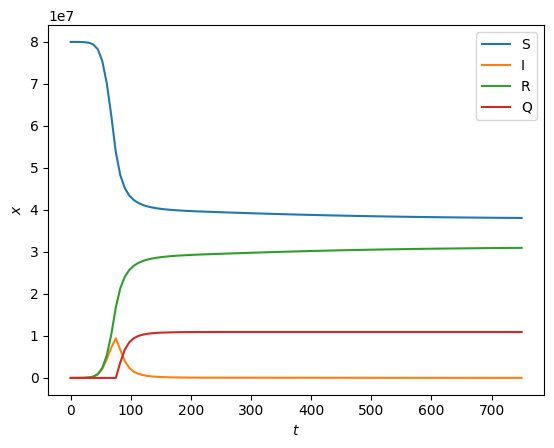

In [137]:
plt.plot(t, x1)
plt.plot(t, x2)
plt.plot(t, x3)
plt.plot(t, x4)
plt.xlabel('$t$')
plt.ylabel('$x$')
plt.legend(['S','I','R','Q'])
plt.show()


#plt.plot(t, u,'r--')
#plt.xlabel('$t$')
#plt.ylabel('$u$')
#plt.legend(['NODE','DAE'])

plt.show()

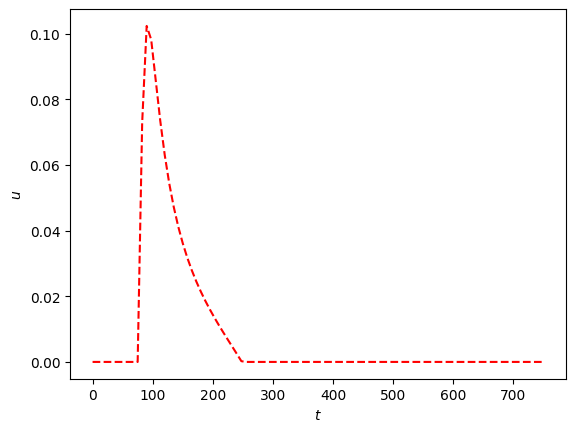

In [138]:
plt.plot(t, u,'r--')
plt.xlabel('$t$')
plt.ylabel('$u$')


plt.show()

In [46]:
model(np.array([0.68,0.27,126333,0.723,0.407,108,325,419,12.95,75.29,261.7]).reshape(1,-1))


<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.2412913]], dtype=float32)>

In [55]:
model(np.array([0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5]).reshape(1,-1))

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.37931445]], dtype=float32)>

In [65]:
u_true=u

In [83]:
m=ConcreteModel()
m.tf=Param(initialize=750)
m.t =ContinuousSet(bounds=(0,m.tf))

In [84]:
m.x1=Var(m.t,initialize=0.326,bounds=(0,1))
m.x2=Var(m.t,initialize=0.5,bounds=(0,1))
m.x3=Var(m.t,initialize=0.5,bounds=(0,1))
m.x4=Var(m.t,initialize=0.5,bounds=(0,1))
m.x5=Var(m.t,initialize=0.5,bounds=(0,1))
m.x6=Var(m.t,initialize=0.5,bounds=(0,1))
m.x7=Var(m.t,initialize=0.5,bounds=(0,1))
m.x8=Var(m.t,initialize=0.5,bounds=(0,1))
m.x9=Var(m.t,initialize=0.5,bounds=(0,1))
m.x10=Var(m.t,initialize=0.5,bounds=(0,1))
m.x11=Var(m.t,initialize=0.5,bounds=(0,1))

discretizer = TransformationFactory('dae.collocation')
discretizer.apply_to(m, nfe=100, ncp=1, scheme='LAGRANGE-RADAU')

m.U=Var(m.t,initialize=0.326,bounds=(0,1))
m.U_true=Var(m.t)
i=0
for t in m.t:
  m.U_true[t].fix(u_true[i]*10)
  i=i+1
net=load_keras_sequential(model)
formulation = ReducedSpaceNNFormulation(net)
m.nn=Block(m.t)
for t in m.t:
  m.nn[t].m=OmltBlock()
  m.nn[t].m.build_formulation(formulation)

def mse_rule(model):
    return sum((model.U[t] - model.U_true[t])**2 for t in model.t) / len(model.t)

m.MSE = Objective(rule=mse_rule, sense=minimize)

In [ ]:
m.x1=Var(m.t,initialize=0.326,bounds=(0.326,0.9975))
m.x2=Var(m.t,initialize=0.5,bounds=(0,1))
m.x3=Var(m.t,initialize=5,bounds=(0,721732))
m.x4=Var(m.t,initialize=0.5,bounds=(0,1))
m.x5=Var(m.t,initialize=0.5,bounds=(0,1))
m.x6=Var(m.t,initialize=100,bounds=(44,250))
m.x7=Var(m.t,initialize=100,bounds=(45,539))
m.x8=Var(m.t,initialize=500,bounds=(17,739))
m.x9=Var(m.t,initialize=10,bounds=(5,20))
m.x10=Var(m.t,initialize=65,bounds=(47,94))
m.x11=Var(m.t,initialize=300,bounds=(29,543))


discretizer = TransformationFactory('dae.collocation')
discretizer.apply_to(m, nfe=100, ncp=1, scheme='LAGRANGE-RADAU')

net=load_keras_sequential(model)
formulation = ReluComplementarityFormulation(net)
m.nn=Block(m.t)
for t in m.t:
  m.nn[t].m=OmltBlock()
  m.nn[t].m.build_formulation(formulation)

In [48]:
for t in m.t:
  m.x1[t].fix(0.5)
  m.x2[t].fix(0.5)
  m.x3[t].fix(0.5)
  m.x4[t].fix(0.5)
  m.x5[t].fix(0.5)
  m.x6[t].fix(0.5)
  m.x7[t].fix(0.5)
  m.x8[t].fix(0.5)
  m.x9[t].fix(0.5)
  m.x10[t].fix(0.5)
  m.x11[t].fix(0.5)
  #m.U[t].fix(0.0200043872)

In [85]:
def _con_in1(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x1[t] == m.nn[t].m.inputs[0]  #x1
def _con_in2(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x2[t] == m.nn[t].m.inputs[1]  #x1
def _con_in3(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x3[t] == m.nn[t].m.inputs[2]  #x1
def _con_in4(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x4[t] == m.nn[t].m.inputs[3]  #x1
def _con_in5(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x5[t] == m.nn[t].m.inputs[4]  #x1
def _con_in6(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x6[t] == m.nn[t].m.inputs[5]  #x1
def _con_in7(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x7[t] == m.nn[t].m.inputs[6]  #x1
def _con_in8(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x8[t] == m.nn[t].m.inputs[7]  #x1
def _con_in9(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x9[t] == m.nn[t].m.inputs[8]  #x1
def _con_in10(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x10[t] == m.nn[t].m.inputs[9]  #x1
def _con_in11(m,t):
  #if t==0:
   # return Constraint.Skip
  return m.x11[t] == m.nn[t].m.inputs[10]  #x1



def _con_out1(m,t):
  #if t==0:
  #  return Constraint.Skip
  return m.U[t]== m.nn[t].m.outputs[0]  #dX V P S U


In [86]:
m.out1=Constraint(m.t, rule=_con_out1)

m.in1=Constraint(m.t, rule=_con_in1)
m.in2=Constraint(m.t, rule=_con_in2)
m.in3=Constraint(m.t, rule=_con_in3)
m.in4=Constraint(m.t, rule=_con_in4)
m.in5=Constraint(m.t, rule=_con_in5)
m.in6=Constraint(m.t, rule=_con_in6)
m.in7=Constraint(m.t, rule=_con_in7)
m.in8=Constraint(m.t, rule=_con_in8)
m.in9=Constraint(m.t, rule=_con_in9)
m.in10=Constraint(m.t, rule=_con_in10)
m.in11=Constraint(m.t, rule=_con_in11)

In [87]:
solver = SolverFactory('ipopt')

results = solver.solve(m, tee=True)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [141]:
#u_pred = []
#u_true = []
t_u = []
x1=[]
x2=[]

print(sorted(m.t))

for i in sorted(m.t):
    t_u.append(i)
    #u_pred.append(value(m.U[i]))
    #u_true.append(value(m.U_true[i]))
    x1.append(value(m.x1[i]))
    x2.append(value(m.x2[i]))

[0, 7.5, 15.0, 22.5, 30.0, 37.5, 45.0, 52.5, 60.0, 67.5, 75.0, 82.5, 90.0, 97.5, 105.0, 112.5, 120.0, 127.5, 135.0, 142.5, 150.0, 157.5, 165.0, 172.5, 180.0, 187.5, 195.0, 202.5, 210.0, 217.5, 225.0, 232.5, 240.0, 247.5, 255.0, 262.5, 270.0, 277.5, 285.0, 292.5, 300.0, 307.5, 315.0, 322.5, 330.0, 337.5, 345.0, 352.5, 360.0, 367.5, 375.0, 382.5, 390.0, 397.5, 405.0, 412.5, 420.0, 427.5, 435.0, 442.5, 450.0, 457.5, 465.0, 472.5, 480.0, 487.5, 495.0, 502.5, 510.0, 517.5, 525.0, 532.5, 540.0, 547.5, 555.0, 562.5, 570.0, 577.5, 585.0, 592.5, 600.0, 607.5, 615.0, 622.5, 630.0, 637.5, 645.0, 652.5, 660.0, 667.5, 675.0, 682.5, 690.0, 697.5, 705.0, 712.5, 720.0, 727.5, 735.0, 742.5, 750]


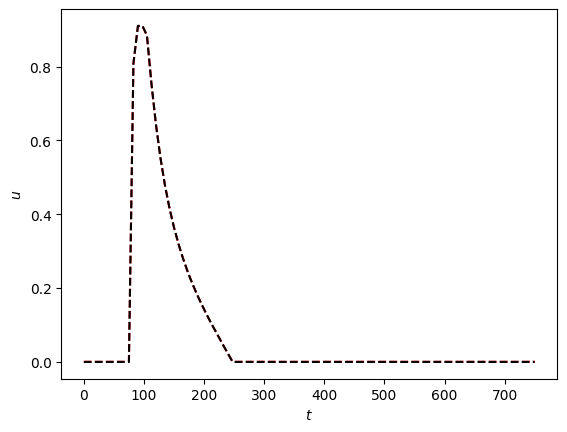

In [99]:
plt.plot(t_u, u_pred,'r--')
plt.plot(t_u, u_true,'k--')
plt.xlabel('$t$')
plt.ylabel('$u$')


plt.show()

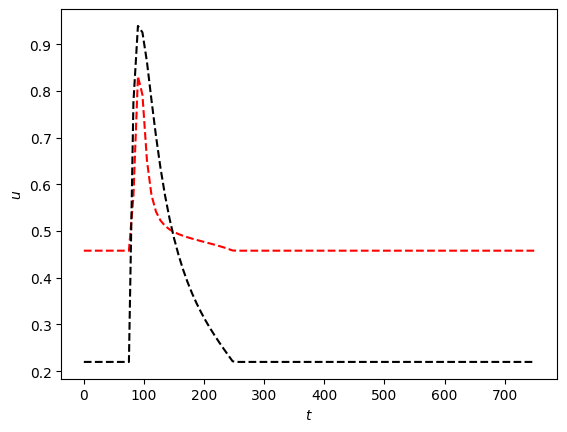

In [142]:
plt.plot(t_u, x1,'r--')
plt.plot(t_u, x2,'k--')
plt.xlabel('$t$')
plt.ylabel('$u$')


plt.show()

In [52]:
m.nn[0].m.inputs[2].pprint()

{Member of inputs} : Size=11, Index=nn[0].m.inputs_set
    Key : Lower : Value : Upper : Fixed : Stale : Domain
      2 :  None :   0.5 :  None : False : False :  Reals


In [88]:
m.U[0].pprint()

{Member of U} : Size=101, Index=t
    Key : Lower : Value                  : Upper : Fixed : Stale : Domain
      0 :     0 : 0.00043049746600208193 :     1 : False : False :  Reals


In [ ]:
import plotly.graph_objects as go
import numpy as np

title = 'Main Source for News'
labels = ['Television', 'Newspaper', 'Internet', 'Radio']
colors = ['rgb(67,67,67)', 'rgb(115,115,115)', 'rgb(49,130,189)', 'rgb(189,189,189)']

mode_size = [8, 8, 12, 8]
line_size = [2, 2, 4, 2]

x_data = np.vstack((np.arange(2001, 2014),)*4)

y_data = np.array([
    [74, 82, 80, 74, 73, 72, 74, 70, 70, 66, 66, 69],
    [45, 42, 50, 46, 36, 36, 34, 35, 32, 31, 31, 28],
    [13, 14, 20, 24, 20, 24, 24, 40, 35, 41, 43, 50],
    [18, 21, 18, 21, 16, 14, 13, 18, 17, 16, 19, 23],
])

fig = go.Figure()

for i in range(0, 4):
    fig.add_trace(go.Scatter(x=x_data[i], y=y_data[i], mode='lines',
        name=labels[i],
        line=dict(color=colors[i], width=line_size[i]),
        connectgaps=True,
    ))

    # endpoints
    fig.add_trace(go.Scatter(
        x=[x_data[i][0], x_data[i][-1]],
        y=[y_data[i][0], y_data[i][-1]],
        mode='markers',
        marker=dict(color=colors[i], size=mode_size[i])
    ))

fig.update_layout(
    xaxis=dict(
        showline=True,
        showgrid=False,
        showticklabels=True,
        linecolor='rgb(204, 204, 204)',
        linewidth=2,
        ticks='outside',
        tickfont=dict(
            family='Arial',
            size=12,
            color='rgb(82, 82, 82)',
        ),
    ),
    yaxis=dict(
        showgrid=False,
        zeroline=False,
        showline=False,
        showticklabels=False,
    ),
    autosize=False,
    margin=dict(
        autoexpand=False,
        l=100,
        r=20,
        t=110,
    ),
    showlegend=False,
    plot_bgcolor='white'
)

annotations = []

# Adding labels
for y_trace, label, color in zip(y_data, labels, colors):
    # labeling the left_side of the plot
    annotations.append(dict(xref='paper', x=0.05, y=y_trace[0],
                                  xanchor='right', yanchor='middle',
                                  text=label + ' {}%'.format(y_trace[0]),
                                  font=dict(family='Arial',
                                            size=16),
                                  showarrow=False))
    # labeling the right_side of the plot
    annotations.append(dict(xref='paper', x=0.95, y=y_trace[11],
                                  xanchor='left', yanchor='middle',
                                  text='{}%'.format(y_trace[11]),
                                  font=dict(family='Arial',
                                            size=16),
                                  showarrow=False))
# Title
annotations.append(dict(xref='paper', yref='paper', x=0.0, y=1.05,
                              xanchor='left', yanchor='bottom',
                              text='Main Source for News',
                              font=dict(family='Arial',
                                        size=30,
                                        color='rgb(37,37,37)'),
                              showarrow=False))
# Source
annotations.append(dict(xref='paper', yref='paper', x=0.5, y=-0.1,
                              xanchor='center', yanchor='top',
                              text='Source: PewResearch Center & ' +
                                   'Storytelling with data',
                              font=dict(family='Arial',
                                        size=12,
                                        color='rgb(150,150,150)'),
                              showarrow=False))

fig.update_layout(annotations=annotations)

fig.show()

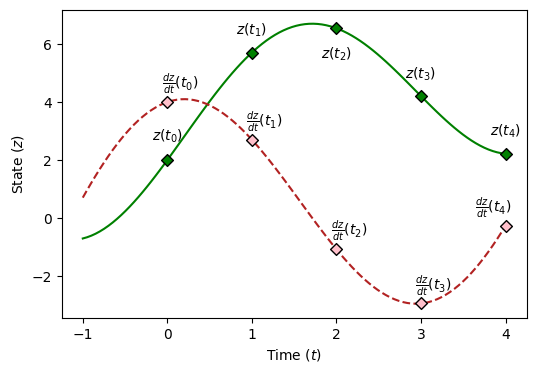

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Sample time points
time_points = [0, 1, 2, 3, 4]

# Define a polynomial function for the state 'x'
def polynomial_function(t):
    return 0.5 * t**2 - t + 2 +5*np.sin(t)
def deriv_function(t):
    return  t - 1 +5*np.cos(t)
t_values = np.linspace(-1, 4, 100)
# Compute the state and derivative values
state_values = [polynomial_function(t) for t in time_points]
derivative_values = [deriv_function(t) for t in t_values]  # Derivative of the polynomial
deriv_values = [deriv_function(t) for t in time_points]
# Labels for the points
point_labels = ['$z(t_0)$', '$z(t_1)$', '$z(t_2)$', '$z(t_3)$', '$z(t_4)$']
d_point_labels = [r'$\frac{dz}{dt} (t_0)$', r'$\frac{dz}{dt} (t_1)$', r'$\frac{dz}{dt} (t_2)$', r'$\frac{dz}{dt} (t_3)$', r'$\frac{dz}{dt} (t_4)$']

# Create a Matplotlib figure
fig, ax = plt.subplots(figsize=(6,4))

# Plot the state profile 'x' over time

for t, x, label in zip(time_points, deriv_values, d_point_labels):
  if t==4:
      ax.annotate(label, (t-0.15, x), textcoords="offset points", xytext=(0, 10), ha='center')
  else:
      ax.annotate(label, (t+0.15, x), textcoords="offset points", xytext=(0, 10), ha='center')
# Annotate the points with labels
for t, x, label in zip(time_points, state_values, point_labels):
    if t==0:
      ax.annotate(label, (t, x+0.2), textcoords="offset points", xytext=(0, 10), ha='center')
    elif t==2:
      ax.annotate(label, (t, x-1.5), textcoords="offset points", xytext=(0, 10), ha='center')
    else:
      ax.annotate(label, (t, x+0.15), textcoords="offset points", xytext=(0, 10), ha='center')

# Add labeled arrows for dx/dt(t_0) and dx/dt(t_3)
arrow_coords = [(0, 2), (2, polynomial_function(2))]
arrow_labels = ['dz/dt(t_0)', 'dz/dt(t_3)']
i=0
for coord, label in zip(arrow_coords, arrow_labels):

    #if i<1:
      #ax.arrow(coord[0], coord[1], 0.25, 1, head_width=0.05, head_length=0.05, fc='red', ec='red')
      #ax.annotate(label, coord, textcoords="offset points", xytext=(0, 10), ha='center')
    #else:
      #ax.arrow(coord[0], coord[1], 1/1.08/2, -1/2, head_width=0.05, head_length=0.05, fc='red', ec='red')
      #ax.annotate(label, coord, textcoords="offset points", xytext=(0, 10), ha='center')
    i=i+1
#ax.annotate(r' $ \frac{dz}{dt} (t_0)$',(0.5,2), textcoords="offset points", xytext=(0, 10), ha='center')
#ax.annotate(r' $ \frac{dz}{dt} (t_2)$',(2,5.9), textcoords="offset points", xytext=(0, 10), ha='center')
# Plot the polynomial function

x_values = [polynomial_function(t) for t in t_values]
ax.plot(t_values, x_values, linestyle='-',color='g')
ax.plot(t_values, derivative_values, linestyle='--',color='firebrick')
ax.scatter(time_points, state_values, marker='D',color='g',edgecolors='k',zorder=2.5)
ax.scatter(time_points, deriv_values, marker='D',color='pink',edgecolors='k',zorder=2.5)
# Set labels, title, and legend
ax.set_xlabel('Time ($t$)')
ax.set_ylabel('State ($z$)')
#ax.grid(True)
plt.savefig('Node1.png', dpi=300)
# Show the figure
plt.show()

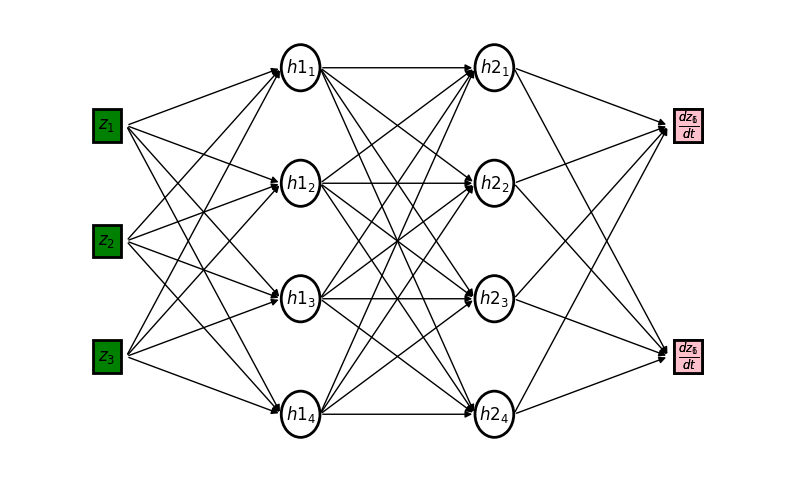

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a figure and an axis
fig, ax = plt.subplots(figsize=(10, 6))

# Function to draw a neuron with different shapes
def draw_neuron(ax, center, radius=0.2, label=None, shape='circle', color='white', edgecolor='black'):
    if shape == 'circle':
        neuron = patches.Circle(center, radius, edgecolor=edgecolor, facecolor=color, lw=2)
    elif shape == 'diamond':
        neuron = patches.RegularPolygon(center, numVertices=4, radius=radius, edgecolor=edgecolor, facecolor=color, lw=2, orientation=np.pi/4)
    elif shape == 'square':
        neuron = patches.Rectangle((center[0]-radius/np.sqrt(2), center[1]-radius/np.sqrt(2)), 2*radius/np.sqrt(2), 2*radius/np.sqrt(2), edgecolor=edgecolor, facecolor=color, lw=2)
    ax.add_patch(neuron)
    if label:
        ax.text(center[0], center[1], label, ha='center', va='center', fontsize=12)

# Draw input neurons (z)
input_neurons = [(1, 4), (1, 3), (1, 2)]
for i, neuron in enumerate(input_neurons):
    draw_neuron(ax, neuron, label=f'$z_{i+1}$', shape='diamond', color='green')

# Draw first hidden layer neurons
hidden_neurons_1 = [(3, 4.5), (3, 3.5), (3, 2.5), (3, 1.5)]
for i, neuron in enumerate(hidden_neurons_1):
    draw_neuron(ax, neuron, label=f'$h1_{i+1}$')

# Draw second hidden layer neurons
hidden_neurons_2 = [(5, 4.5), (5, 3.5), (5, 2.5), (5, 1.5)]
for i, neuron in enumerate(hidden_neurons_2):
    draw_neuron(ax, neuron, label=f'$h2_{i+1}$')

# Draw output neuron (dz/dt)
output_neuron = [(7, 2),(7, 4)]
for i, neuron in enumerate(output_neuron):
    draw_neuron(ax, neuron, label='$\\frac{dz_6}{dt}$', shape='square', color='pink')
    draw_neuron(ax, neuron, label='$\\frac{dz_1}{dt}$', shape='square', color='pink')

# Draw lines between neurons to represent connections
def draw_connection(ax, start, end):
    arrow = patches.FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=10, color='black')
    ax.add_patch(arrow)

# Connections from input to first hidden layer
for start in input_neurons:
    for end in hidden_neurons_1:
        draw_connection(ax, (start[0]+0.2, start[1]), (end[0]-0.2, end[1]))

# Connections from first hidden layer to second hidden layer
for start in hidden_neurons_1:
    for end in hidden_neurons_2:
        draw_connection(ax, (start[0]+0.2, start[1]), (end[0]-0.2, end[1]))

# Connections from second hidden layer to output
for start in hidden_neurons_2:
    for end in output_neuron:
        draw_connection(ax, (start[0]+0.2, start[1]), (end[0]-0.2, end[1]))

# Set axis limits and remove axes
ax.set_xlim(0, 8)
ax.set_ylim(1, 5)
ax.axis('off')

# Show the plot
plt.show()

In [ ]:
import numpy as np
import plotly.graph_objects as go

# Sample time points
time_points = [0, 1, 2, 3, 4]

# Define a polynomial function for the state 'z'
def polynomial_function(t):
    return 0.5 * t**2 - t + 2 + 5 * np.sin(t)

# Compute the state and derivative values
state_values = [polynomial_function(t) for t in time_points]
derivative_values = [t - 1 for t in time_points]  # Derivative of the polynomial

# Labels for the points
point_labels = ['$z(t_0)$', '$z(t_1)$', '$z(t_2)$', '$z(t_3)$', '$z(t_4)$']

# Create a Plotly figure
fig = go.Figure()

# Plot the state profile 'z' over time
fig.add_trace(go.Scatter(
    x=time_points,
    y=[state_values],mode='markers+text',text=point_labels,
    textposition='top center',
    name='State points'
))

# Add labeled arrows for dz/dt(t_0) and dz/dt(t_3)
arrow_coords = [(0, 2), (2, polynomial_function(2))]
arrow_labels = ['dz/dt(t_0)', 'dz/dt(t_3)']
arrow_directions = [(0.25, 1), (1/1.08/2, -1/2)]

for (x_start, y_start), (dx, dy), label in zip(arrow_coords, arrow_directions, arrow_labels):
    fig.add_annotation(
        x=x_start + dx,
        y=y_start + dy,
        ax=x_start,
        ay=y_start,
        xref="x",
        yref="y",
        axref="x",
        ayref="y",
        showarrow=True,
        arrowhead=3,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor='red',
        text=label,
        font=dict(size=12, color="red")
    )

# Annotate the arrows
fig.add_annotation(
    x=0.5, y=2, text=r' $ \frac{dz}{dt} (t_0)$',
    showarrow=False, yshift=10, font=dict(size=12, color="black")
)
fig.add_annotation(
    x=2, y=5.9, text=r' $ \frac{dz}{dt} (t_3)$',
    showarrow=False, yshift=10, font=dict(size=12, color="black")
)

# Plot the polynomial function
t_values = np.linspace(0, 4, 100)
z_values = [polynomial_function(t) for t in t_values]

fig.add_trace(go.Scatter(
    x=t_values,
    y=z_values,
    mode='lines',
    line=dict(dash='dash', color='black'),
    name='Polynomial function'
))

# Set labels and title
fig.update_layout(
    xaxis_title='Time',
    yaxis_title='State (z)',
    title='State Profile Over Time',
    showlegend=False
)

# Show the figure
fig.show()
